# 3D: CNN classification of lanthanide cluster nuclearity — csd2023 pool

Trains the same 1D-CNN architecture as 3C, but on the **csd2023 pool**: 6,644 CSD
structures from the automatic 2023 export (`cifs_nodf`) plus 74 manually verified
nuclearity-1 structures (renamed to the `cifs_nodf` naming convention), 6,718 CIFs total.

**Label scheme (binned, 11 classes):** classes 1–9 = own nuclearity; class 10 =
"10+" (finite clusters with nuclearity >= 10); class 11 = coordination polymers
(prefix `p`). PDFs calculated with `pyobjcryst` + Debye PDF calculator at
Q = 0.3–11 Å⁻¹, rmax = 20 Å; training uses the r = 2–12 Å slice.

**Comparison with 3C:** this dataset is ~10x larger (6,718 vs ~700 structures) but
heavily imbalanced (nuclearity 2 dominates with ~4,000 structures; classes 7 and 9
have < 20 each). Stratified splits are used; per agreement, NO class weighting is
applied. Labels are pre-written by the pool-build script (order = sorted glob of
the calculated PDFs); CIFs whose PDF failed the |G(r)| <= 100 sanity check (or
failed to calculate) are excluded from the labels file and thus from training.

CV fold checkpoints + histories are persisted after each fold so that a node
death mid-run only costs the current stage (re-executing this notebook resumes
the CV from completed folds).

In [5]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import math

# Python 3.7 compatibility for keras_tuner (uses math.prod)
if not hasattr(math, "prod"):
    def _prod(values):
        result = 1
        for value in values:
            result *= int(value)
        return result

    math.prod = _prod

In [2]:
# Import path configuration
import sys
import importlib
sys.path.insert(0, '..')  # Add parent directory to path

# Force reload to pick up any config changes
import config
from config import setup_workdir, get_path
# Set working directory to CSD calculated PDFs
setup_workdir('csd_calculated_pdfs')

Working directory: /Volumes/Extreme SSD/WORK/PDF/PDF-NN paper/PDF-NN/pdf-nn-data/csd_structures/calculated_pdfs


In [ ]:
# Get calculated PDFs from the csd2023 pool
csd_pdfs_dir = get_path('csd2023_calculated_pdfs')
files_calc = sorted(glob.glob(str(csd_pdfs_dir / '*.dat')))
print(f"{len(files_calc)} calculated PDFs in {csd_pdfs_dir}")

In [ ]:
from collections import defaultdict
import re
import matplotlib.pyplot as plt

def label_from_filename(filename):
    """Binned 11-class label from the csd2023 naming convention.
    Leading digits -> nuclearity (>= 10 binned to 10); 'p' prefix -> polymer (11)."""
    name = os.path.basename(filename)
    if name[0] == 'p':
        return 11
    m = re.match(r'^(\d+)', name)
    n = int(m.group(1))
    return 10 if n >= 10 else n

def analyze_filenames(filenames):
    counts = defaultdict(int)
    for filepath in filenames:
        counts[label_from_filename(filepath)] += 1
    return counts

counts = analyze_filenames(files_calc)
class_names = {c: ('polymer' if c == 11 else ('10+' if c == 10 else str(c))) for c in range(1, 12)}
sorted_counts = {class_names[d]: counts.get(d, 0) for d in range(1, 12)}

print("Counts of csd2023 structures by binned class:", sorted_counts)
print(f"Total number of structures: {len(files_calc)}")

plt.figure(figsize=(10, 5))
plt.bar(list(sorted_counts.keys()), list(sorted_counts.values()), color='steelblue')
plt.xlabel('Binned nuclearity class')
plt.ylabel('Counts')
plt.title('Distribution of csd2023 pool structures by binned nuclearity')
plt.show()

In [ ]:
# Setup output directories for the csd2023 pool
labels_dir = get_path('labels')
models_dir = get_path('csd2023_models')
models_dir.mkdir(parents=True, exist_ok=True)

# Labels were pre-written by the pool-build script; order = sorted(*.dat) glob.
# Regenerated 2026-09-09 for the full 6806-file recalculated set (dedup +
# PDFCalculator + Uiso fix) — no exclusions remain.
labels_file = labels_dir / 'csd2023_labels.txt'
labels_list = labels_file.read_text().split()
assert len(labels_list) == len(files_calc), \
    f"labels ({len(labels_list)}) != calculated PDFs ({len(files_calc)}); regenerate labels"

# FULL r-range input: 0-20 A, 2000 points at 0.01 A step (rmax=20 grid).
# The 3C comparison run keeps the published 2-12 A slice; this dataset uses
# the whole curve (ligand fingerprints 1.2-1.5 A + long-range periodicity).
raw_data_points = []
for f in files_calc:
    df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, engine='python')
    raw_data_points.append(df.values.ravel())

raw_data_points = np.array(raw_data_points)
assert raw_data_points.shape[1] == 2000, raw_data_points.shape
labels_binned = np.array([int(x) for x in labels_list])
# classes on disk are 1..11; Keras sparse CE + 11-unit softmax needs 0..10
labels = labels_binned - 1

print(f"Labels loaded from: {labels_file}")
print(f"Input vectors: {raw_data_points.shape}")
print(f"Models will be saved to: {models_dir}")


2


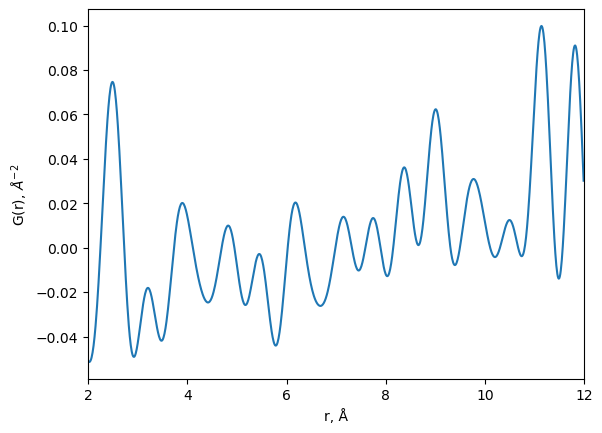

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
# Per-sample z-scoring (2026-09-10): mean 0 / std 1 per PDF (see 3C note).
data_points = (raw_data_points - raw_data_points.mean(axis=1, keepdims=True)) / raw_data_points.std(axis=1, keepdims=True)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[77,:]))/100+2, data_points[77,:])
plt.xlabel('r, Å')
plt.ylabel('G(r), $Å^{-2}$')
print(labels_binned[77])

In [8]:
# Hyperparameter tuning (input: full 0-20 A, 2000 points)

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(2000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [9]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42, stratify=labels)

In [ ]:
# Setup hyperband directory within the csd2023 models folder
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=200,
    factor=3,
    directory=str(models_dir),
    project_name='hyperband_csd2023',
    overwrite = True
)

tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=10)])
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hyperparameters.values)

# Extract best hyperparameters for retraining
best_filters1 = best_hyperparameters.get('filters1')
best_kernel_size1 = best_hyperparameters.get('kernel_size1')
best_filters2 = best_hyperparameters.get('filters2')
best_kernel_size2 = best_hyperparameters.get('kernel_size2')
best_dropout = best_hyperparameters.get('dropout')
best_dense_units = best_hyperparameters.get('dense_units')
best_learning_rate = best_hyperparameters.get('learning_rate')

print(f"\nExtracted hyperparameters for retraining:")
print(f"  filters1: {best_filters1}, kernel_size1: {best_kernel_size1}")
print(f"  filters2: {best_filters2}, kernel_size2: {best_kernel_size2}")
print(f"  dropout: {best_dropout}, dense_units: {best_dense_units}")
print(f"  learning_rate: {best_learning_rate}")

best_model = tuner.get_best_models(num_models=1)[0]

# Save best model to models directory
best_model_path = models_dir / 'tuned_csd2023.h5'
best_model.save(best_model_path)
print(f"\nBest model saved to: {best_model_path}")

In [12]:
# Create model with the tuned best hyperparameters (input: 2000 points).
# Fixed 2026-09-09: this cell was accidentally dropped in an earlier edit,
# crashing the CV stage with NameError: create_model.
def create_model():
    model = Sequential()
    model.add(Conv1D(filters=best_filters1, kernel_size=best_kernel_size1, activation='relu', input_shape=(2000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(best_dropout))
    model.add(Conv1D(filters=best_filters2, kernel_size=best_kernel_size2, activation='relu'))
    model.add(Dropout(best_dropout))
    model.add(Flatten())
    model.add(Dense(units=best_dense_units, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(best_dropout))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=best_learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

num_folds = 5
num_epochs = 200
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1 
all_fold_results = []
histories = []


In [ ]:
# Setup directory for fold models; node-death-resilient CV
folds_dir = models_dir / 'cv_folds'
folds_dir.mkdir(parents=True, exist_ok=True)

# Node-death resilience: persist fold histories + accuracies after each fold;
# on re-run, completed folds (checkpoint exists AND history recorded) are skipped.
import json
hist_file = models_dir / 'cv_histories.json'
if hist_file.exists():
    cv_store = json.loads(hist_file.read_text())
    histories = [keras.callbacks.History() for _ in cv_store['histories']]
    for h, hd in zip(histories, cv_store['histories']):
        h.history = {k: list(v) for k, v in hd.items()}
    all_fold_results = list(cv_store['fold_results'])
else:
    cv_store = {'histories': [], 'fold_results': []}
    histories, all_fold_results = [], []

for fold_num, (train_index, val_index) in enumerate(kf.split(data_points, labels), 1):
    checkpoint_path = folds_dir / f"csd2023_fold_{fold_num}_model.h5"
    if fold_num <= len(all_fold_results) and checkpoint_path.exists():
        print(f'Fold {fold_num} already recorded (acc={all_fold_results[fold_num-1]:.4f}) - skipping')
        continue
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    model = create_model()
    checkpoint = ModelCheckpoint(str(checkpoint_path), monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

    print(f'Training fold {fold_num}...')
    history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    histories.append(history)

    # Load the best model saved by the checkpoint and evaluate
    load_model = keras.models.load_model(str(checkpoint_path))
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)

    all_fold_results.append(val_acc)
    cv_store['histories'] = [h.history for h in histories]
    cv_store['fold_results'] = list(all_fold_results)
    hist_file.write_text(json.dumps(cv_store))

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))
print(f"\nFold models saved to: {folds_dir}")

Loading best model from fold 3: /Volumes/Extreme SSD/WORK/PDF/PDF-NN paper/PDF-NN/pdf-nn-data/models/csd_no_attention/cv_folds/csd_fold_3_model.h5
5/5 [==============================] - 1s 12ms/step
Recall score: [0.94117647 0.95       1.         1.         1.         1.
 1.         1.         0.97297297]
F1 score: [0.94117647 0.96202532 1.         0.97560976 1.         1.
 1.         1.         0.97297297]
Precision score: [0.94117647 0.97435897 1.         0.95238095 1.         1.
 1.         1.         0.97297297]
Confusion matrix, without normalization
[[16  1  0  0  0  0  0  0  0]
 [ 1 38  0  0  0  0  0  0  1]
 [ 0  0  1  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0]
 [ 0  0  0  0  5  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  3  0  0]
 [ 0  0  0  0  0  0  0  5  0]
 [ 0  0  0  1  0  0  0  0 36]]


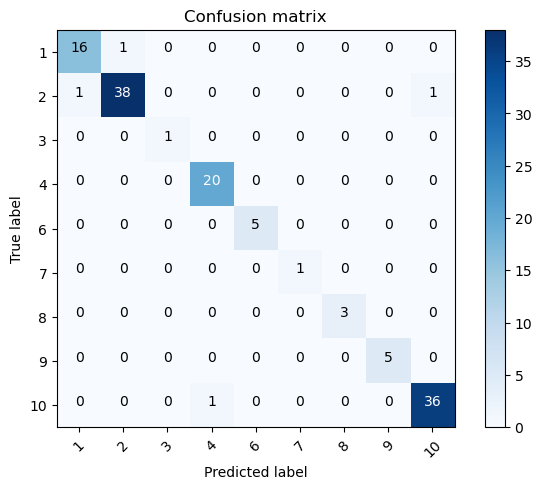

In [15]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Load the best model from cross-validation (best fold determined from training)
best_fold = np.argmax(all_fold_results) + 1  # +1 because fold_num starts at 1
best_model_path = models_dir / 'cv_folds' / f'csd2023_fold_{best_fold}_model.h5'
print(f"Loading best model from fold {best_fold}: {best_model_path}")

load_model = keras.models.load_model(best_model_path)

load_model.evaluate(X_val, y_val)
y_pred_prob = load_model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_val, y_pred)
recall = recall_score(y_val, y_pred, average=None)
f1 = f1_score(y_val, y_pred, average=None)
precision = precision_score(y_val, y_pred, average=None)
#print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_val), title='Confusion matrix', normalize=False)
plt.show()

In [39]:
# Skipping attention weights plot - no attention mechanism in this model version
print("Note: This model does not include an attention mechanism, so attention weight visualization is not applicable.")

Note: This model does not include an attention mechanism, so attention weight visualization is not applicable.


Sample label: 7


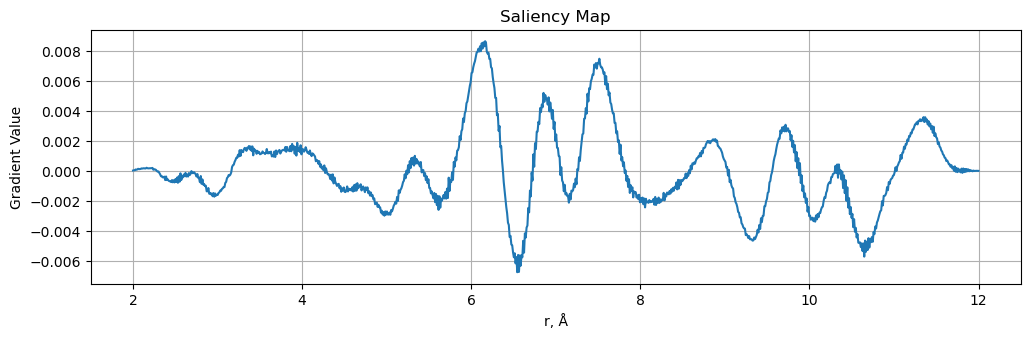

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Use the loaded model from cross-validation
model = load_model

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 6  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 2000, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(2000)
print(f"Sample label (0-based): {y_train[sample_index]}, binned: {y_train[sample_index] + 1}")
angstrom_range = 0 + np.linspace(0, 2000, 2000) / 100

# Plot
plt.figure(figsize=(12, 3.3))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 400
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# Loop through the binned classes 1..11
for label in range(0, 11):
    ax = axes[label // 3, label % 3]
    gradients = []

    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 2000, 1), dtype=tf.float32)

            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label]

            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(2000)
            gradients.append(grad_numpy)

            angstrom_range = 0 + np.linspace(0, 2000, 2000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='royalblue')

    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')

    ax.set_title(f'Label {label + 1}' + (' (polymer)' if label == 10 else (' (10+)' if label == 9 else '')))
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

fig.delaxes(axes[3,2])

plt.tight_layout()

# Save to figures directory
figures_dir = get_path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'csd2023_saliency_maps.png', dpi=400)
plt.show()

## Status

Check run state after (possible) node death / completion:

```bash
ls /workspace/home/pdf-nn-data/models/csd2023/
ls /workspace/home/pdf-nn-data/csd2023/calculated_pdfs | wc -l
tail logs/3D_csd2023.log
```

If the run died mid-CV, re-executing this notebook resumes from the completed
folds (checkpoints + `cv_histories.json` under the models dir). Hyperband is
*not* resumable (`overwrite=True`) and would restart from scratch.